# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">1. EDA for Netflix Customer Churn Dataset</p>

### Introduction About the Data :

**The dataset** The goal is to predict customer `churned` status (Classification Analysis).

There are 14 independent variables (including `customer_id`):

* `customer_id` : unique identifier for each customer
* `age` : Age of the customer
* `gender` : Gender of the customer
* `subscription_type` : Type of subscription (Basic, Standard, Premium)
* `watch_hours` : Total hours watched by the customer
* `last_login_days` : Days since last login
* `region` : Geographic region of the customer
* `device` : Device used to access service (TV, Mobile, Laptop, Desktop, Tablet)
* `monthly_fee` : Monthly subscription fee
* `payment_method` : Payment method used
* `number_of_profiles` : Number of profiles in the account
* `avg_watch_time_per_day` : Average watch time per day
* `favorite_genre` : Favorite content genre

Target variable:
* `churned`: Whether the customer churned (0 = No, 1 = Yes) (Classification).

[Netflix Customer Churn Data](https://www.kaggle.com/)
Dataset Source Link :

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Read the Dataset</p>

### Read Dataset

In [3]:
import pandas as pd
df = pd.read_csv("./data/netflix_customer_churn.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


### Dataset Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

### Drop customer_id column as it is statistically insignificant

In [5]:
df = df.drop(labels=['customer_id'],axis=1)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Check Missing Values in Dataset</p>

In [6]:
df.isna().sum()

age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

### No Missing Values found in the dataset

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Check Duplicates in Dataset</p>

In [7]:
df.duplicated().sum()

np.int64(0)

### No Duplicated data found

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Descriptive Statistics</p>

### Numerical and Categorical columns seperation

In [8]:
numerical_columns = list(df.columns[df.dtypes!='object'])
categorical_columns = list(df.columns[df.dtypes=='object'])
print(f'Numerical Columns   : {numerical_columns}')
print(f'Categorical Columns : {categorical_columns}')

Numerical Columns   : ['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']
Categorical Columns : []


### Numerical Columns Description

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,43.84740,15.501128,18.00,30.0000,44.00,58.00,70.00
watch_hours,5000.0,11.64945,12.014654,0.01,3.3375,8.00,16.03,110.40
last_login_days,5000.0,30.08980,17.536078,0.00,15.0000,30.00,45.00,60.00
monthly_fee,5000.0,13.68340,3.692062,8.99,8.9900,13.99,17.99,17.99
churned,5000.0,0.50300,0.500041,0.00,0.0000,1.00,1.00,1.00
number_of_profiles,5000.0,3.02440,1.415841,1.00,2.0000,3.00,4.00,5.00
avg_watch_time_per_day,5000.0,0.87480,2.619824,0.00,0.1100,0.29,0.72,98.42


### Categorical Columns Description

In [10]:
df[categorical_columns].describe().T

ValueError: Cannot describe a DataFrame without columns

### All unique values in dataset

In [ ]:
df.nunique()

age                         53
gender                       3
subscription_type            3
watch_hours               2343
last_login_days             61
region                       6
device                       5
monthly_fee                  3
churned                      2
payment_method               5
number_of_profiles           5
avg_watch_time_per_day     505
favorite_genre               7
dtype: int64

### Categorical columns include: subscription_type, gender, payment_method, region, device, and favorite_genre

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Univariate Analysis with Visualisation</p>

### Univariate Analysis of Numerical Variables

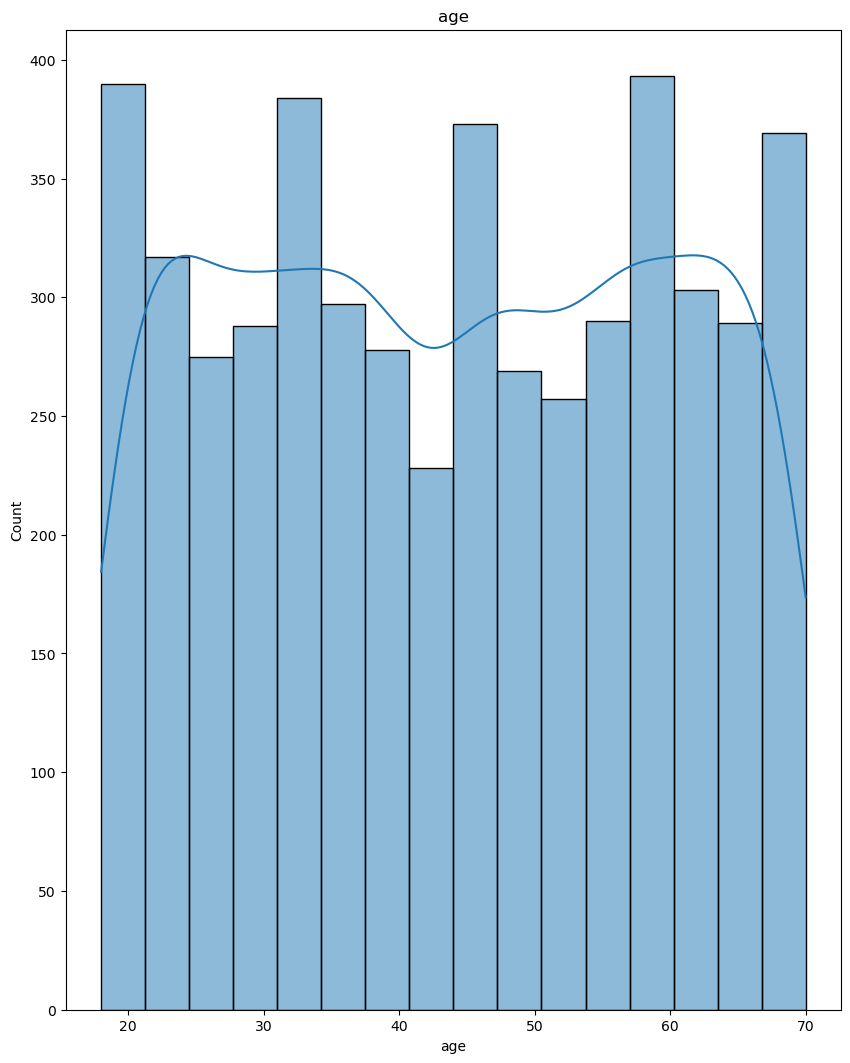

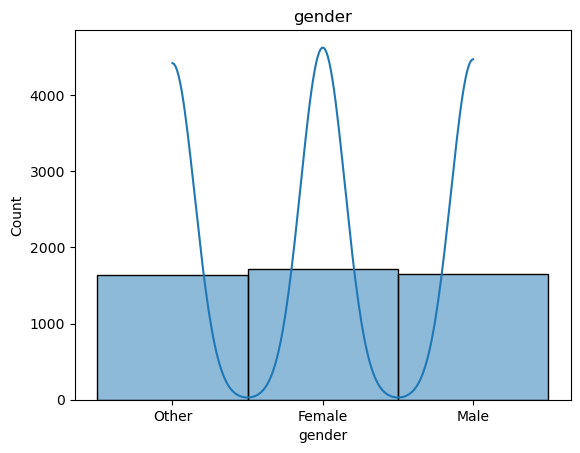

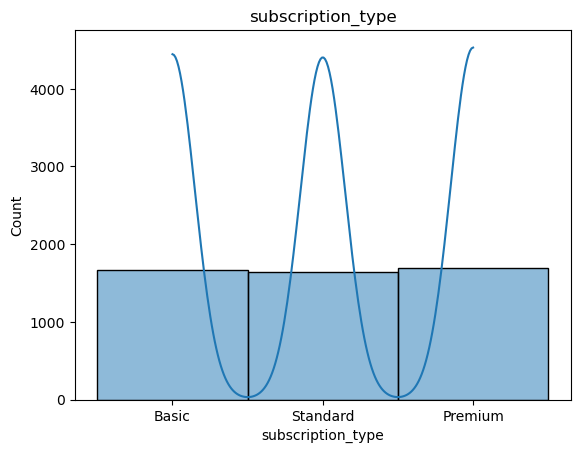

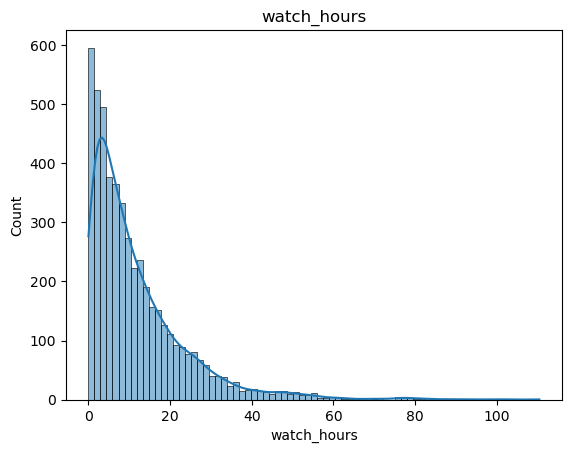

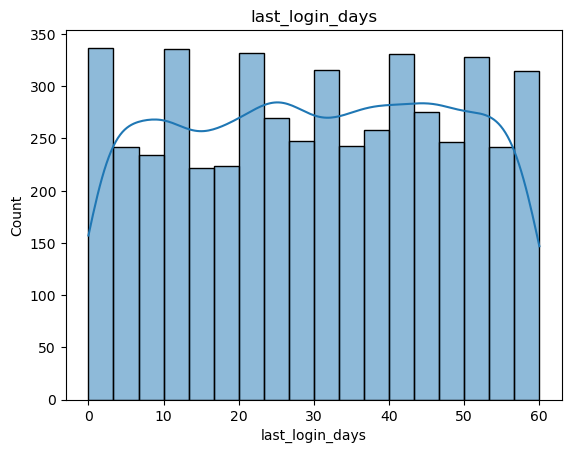

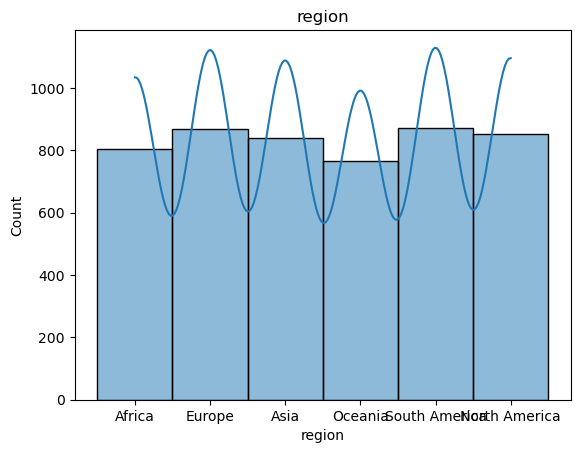

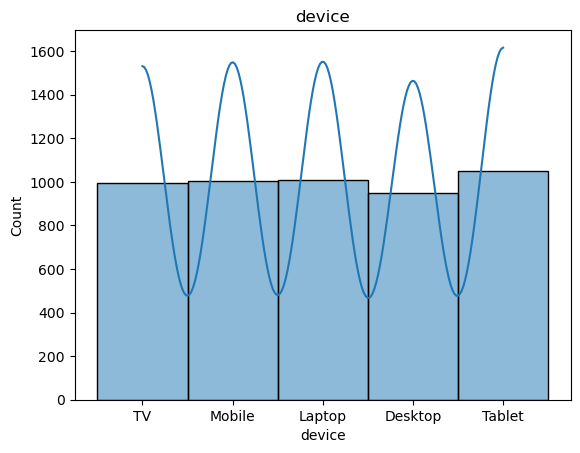

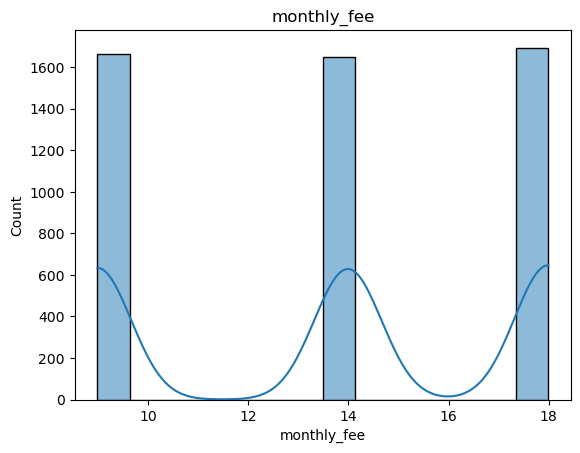

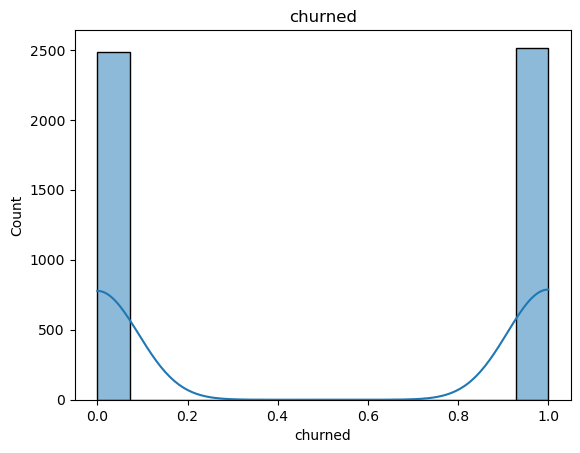

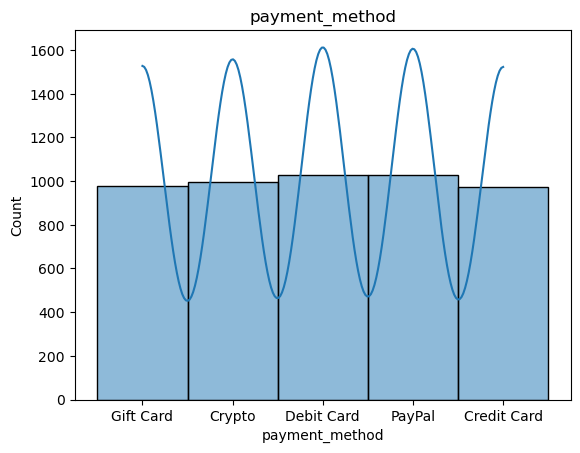

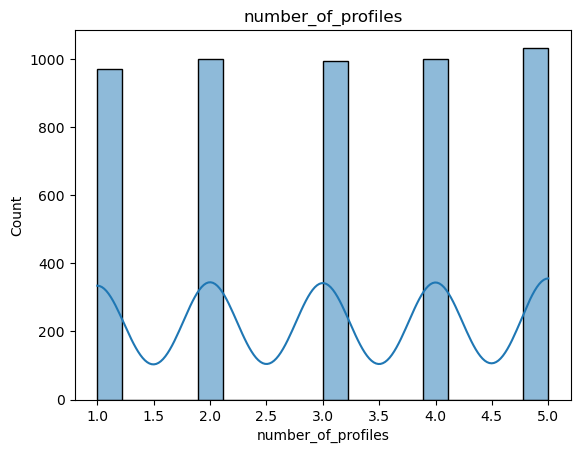

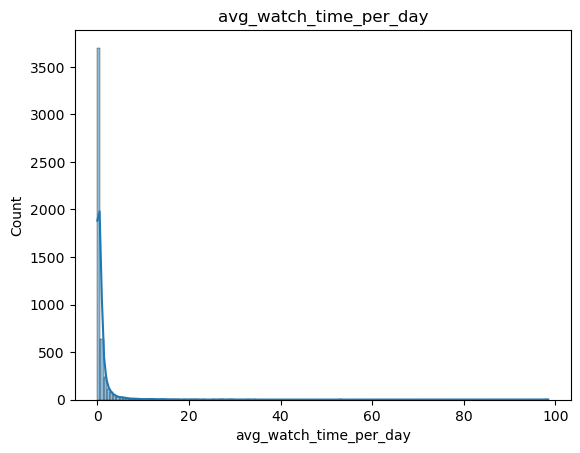

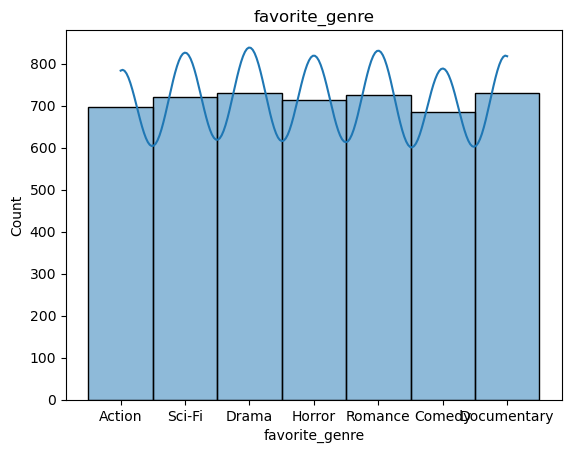

In [12]:
import seaborn as sb
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.5, wspace=0.5)
x = 1
for i in numerical_columns:
    sb.histplot(data = df, x = i, kde=True)
    plt.title(i)
    print('\n')
    plt.show()

### Univariate analysis for categorical variables

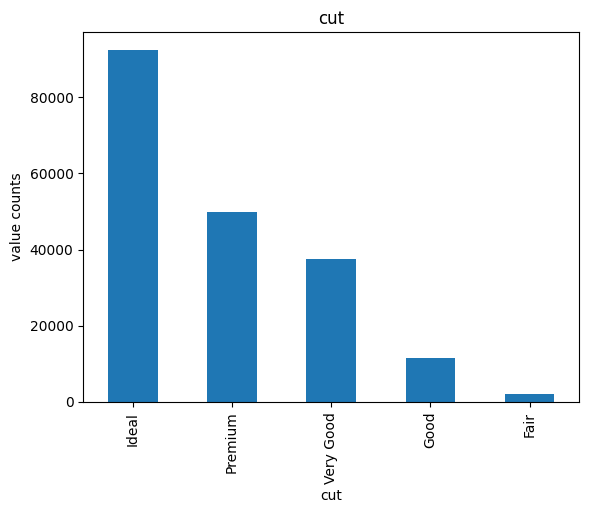

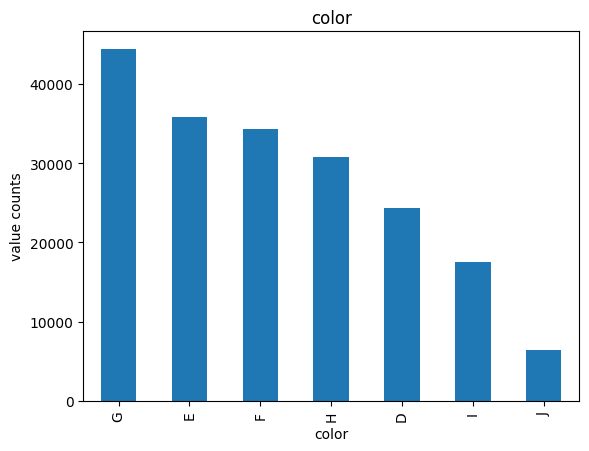

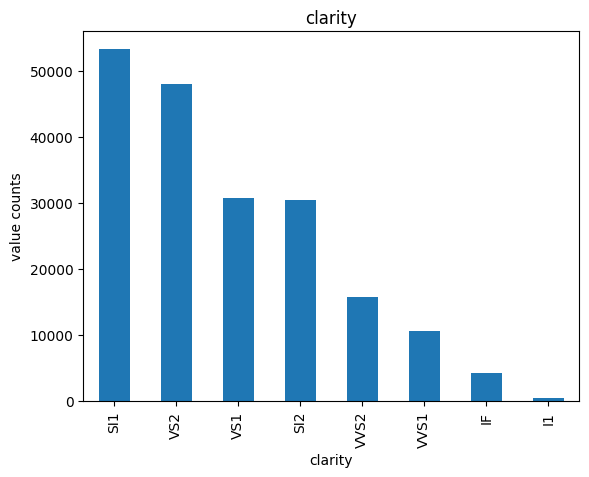

In [11]:
for i in categorical_columns:
    df[i].value_counts().plot(kind='bar', xlabel = i , ylabel='value counts', title = i)
    print('\n')
    plt.show()

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Bivariate Analysis with Visualisation</p>

### Correlation heatmap

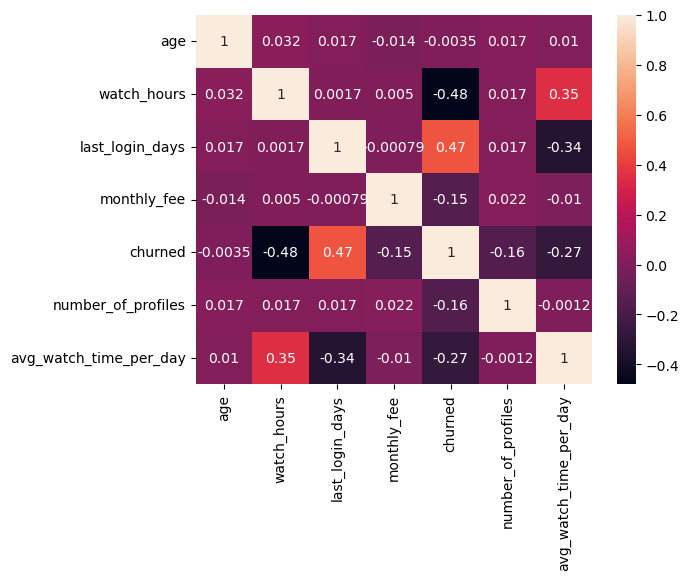

In [13]:
sb.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

### Pairplot

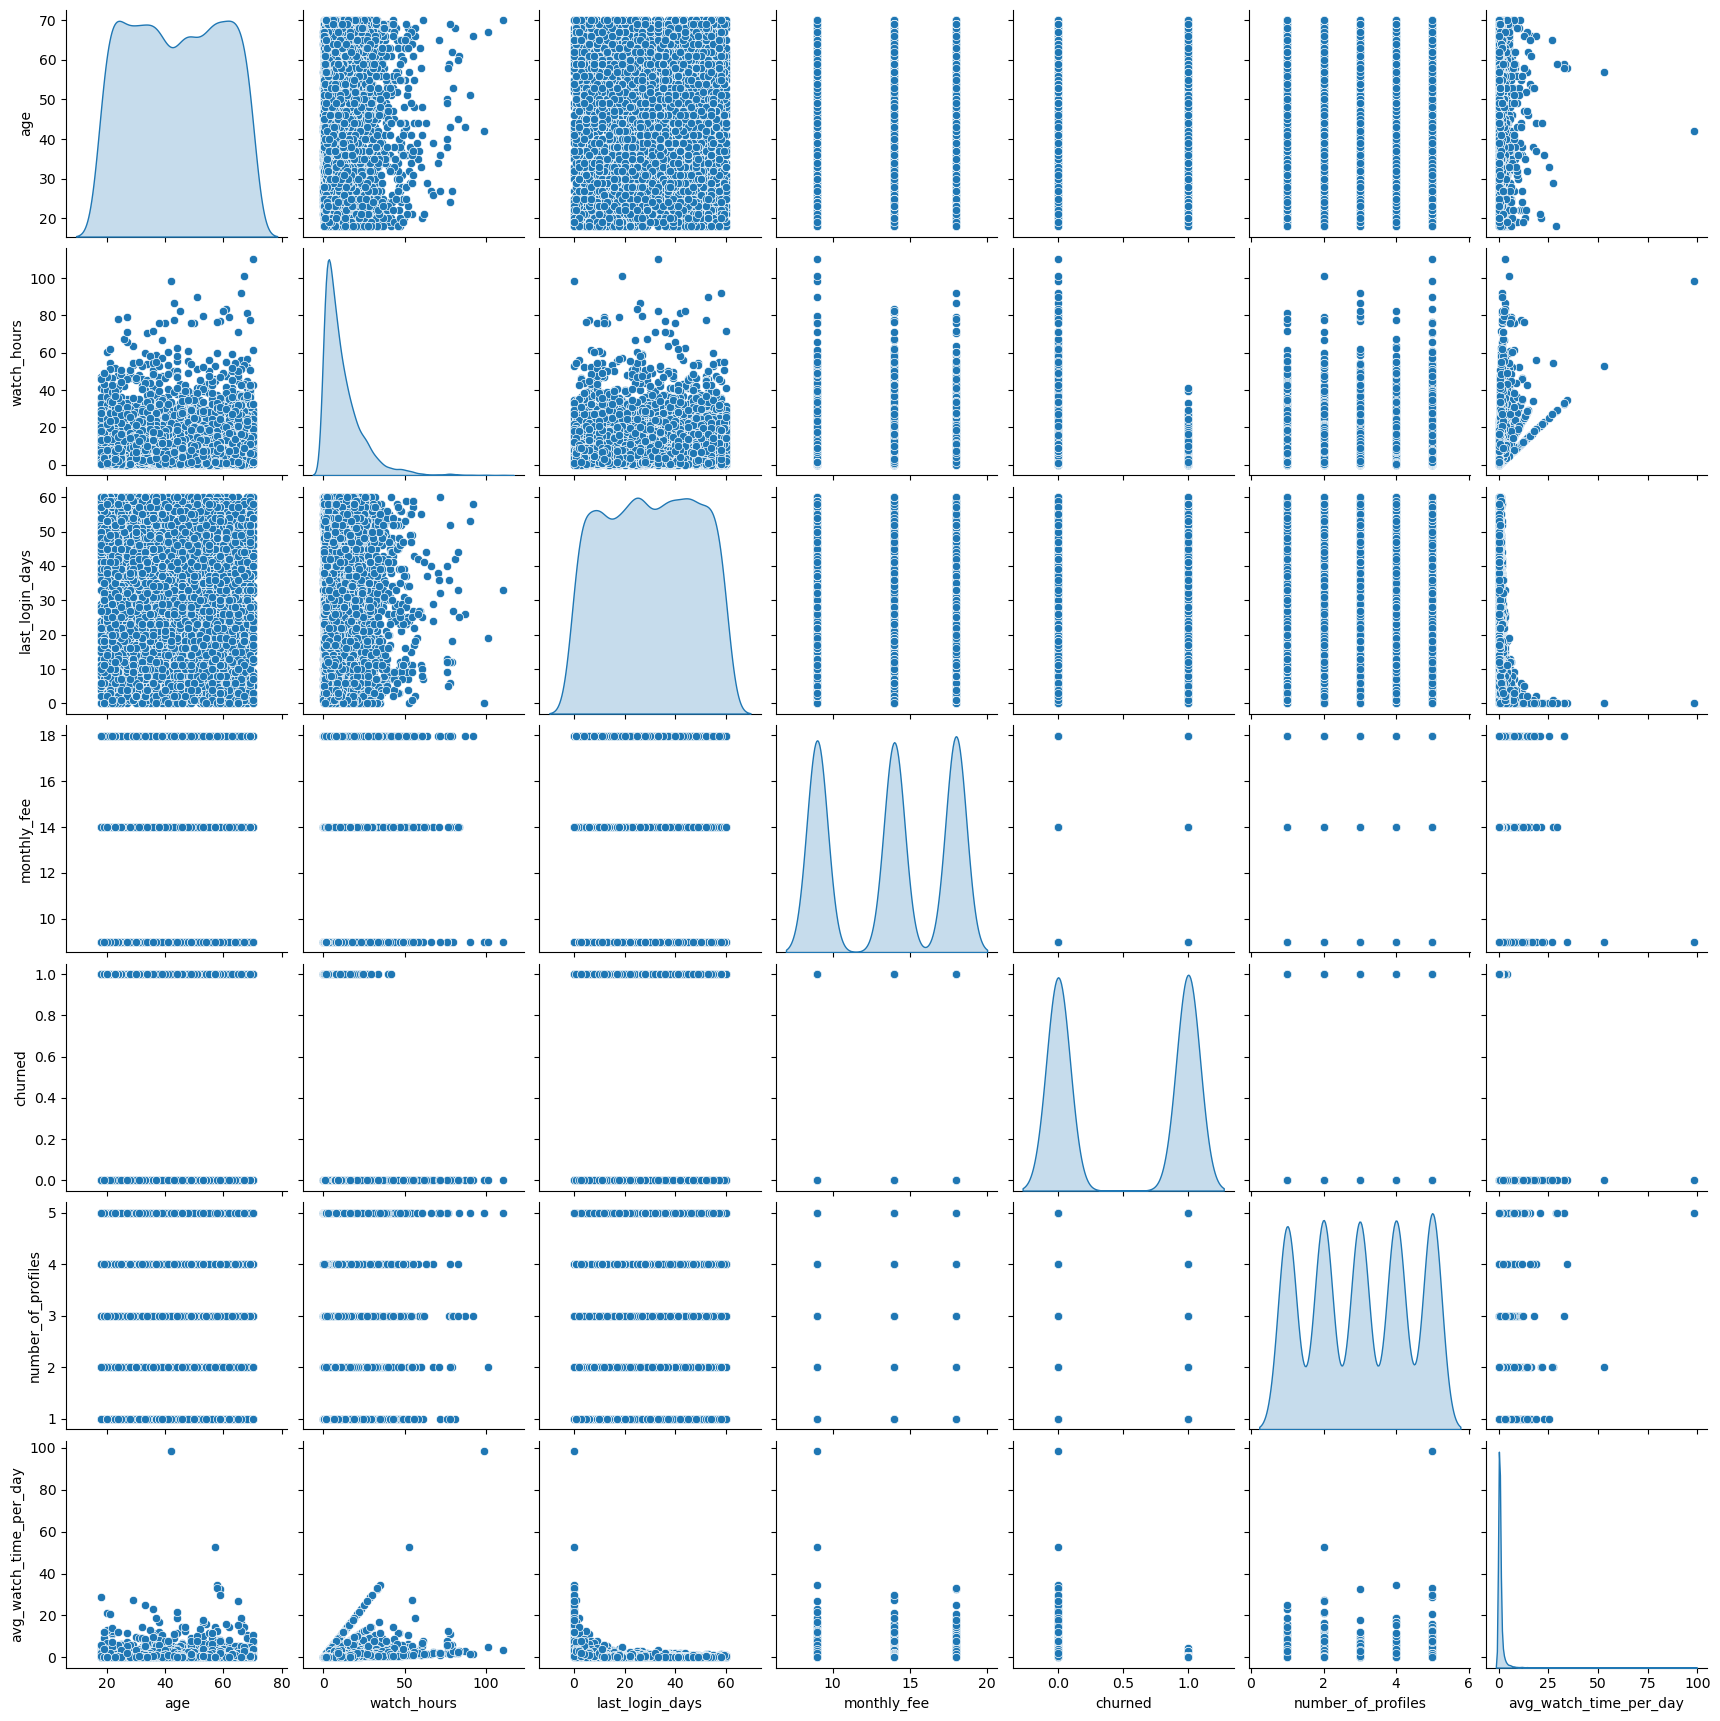

In [14]:
sb.pairplot(df,diag_kind='kde')
plt.show()

## Categorical Features vs Target Feature Churn Countplot

In [19]:
for i in categorical_columns:
    if i != 'churned':
        sb.countplot(data=df, x=i, hue='churned')
        plt.title(f'Churn vs {i}')
        plt.xticks(rotation=45)
        plt.show()

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Categorical Encoding of categorical features</p>

### The categorical variables need to be encoded for machine learning models

### subscription_type has ordinal relationship (Basic < Standard < Premium)
### device can be mapped numerically for better model performance

### Creating Mapper for subscription_type and device

In [20]:
subscription_mapper = {"Basic": 1, "Standard": 2, "Premium": 3}
device_mapper = {"TV": 1, "Mobile": 2, "Laptop": 3, "Desktop": 4, "Tablet": 5}

### Applying the mapper to the dataframe

In [21]:
df['subscription_type'] = df['subscription_type'].replace(subscription_mapper)
df['device'] = df['device'].replace(device_mapper)

In [22]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,1,14.73,29,Africa,1,8.99,1,Gift Card,1,0.49,Action
1,47,Other,2,0.70,19,Europe,2,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,2,16.32,10,Asia,1,13.99,0,Crypto,2,1.48,Drama
3,53,Other,3,4.51,12,Oceania,1,17.99,1,Crypto,2,0.35,Horror
4,56,Other,2,1.89,13,Africa,2,13.99,1,Crypto,2,0.13,Action


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">Mutual Information Scores</p>

### Seperating X and Y

In [23]:
X = df.drop(labels=['churned'],axis=1)
Y = df[['churned']]

### Calculating Mutual Information scores for classification

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Encode the remaining categorical columns before computing MI scores.
X_encoded = pd.get_dummies(X, drop_first=True)
mi_scores = mutual_info_classif(X_encoded, Y.values.flatten(), random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_encoded.columns)
mi_scores = mi_scores.sort_values(ascending=False)

ValueError: could not convert string to float: 'Other'

In [22]:
import numpy as np

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    plt.show()

### Visualizing Mutual Information Scores

carat      1.825115
x          1.674011
y          1.666632
z          1.615992
clarity    0.397911
color      0.285518
table      0.109664
cut        0.092104
depth      0.045643
Name: MI Scores, dtype: float64


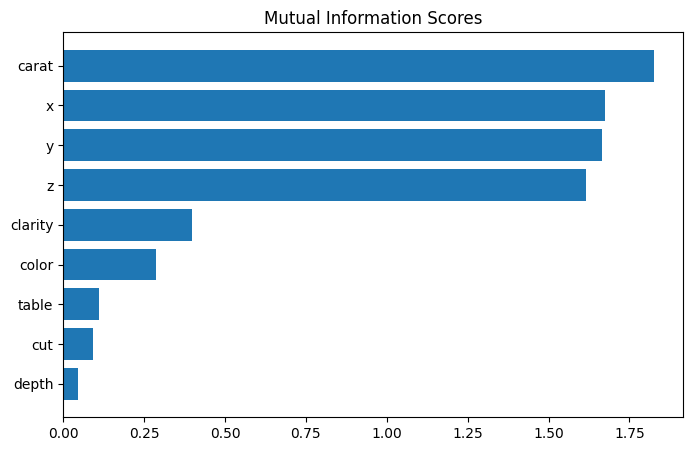

In [23]:
print(mi_scores)
plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

### Conclusion : Above shows the most important features to predict customer churn. Features with higher MI scores have stronger relationship with the target variable (churned).